# A股 Alpha因子 研究

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from typing import List, Optional, Union, Tuple, Dict
from scipy.stats import spearmanr

def rowwise_residuals(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    """
    对 df1 的每一行 y，用 df2 同一行作为 X 做 OLS 回归，输出残差组成的新 DataFrame
    """
    assert df1.shape == df2.shape, "df1 和 df2 的 shape 必须一致"
    
    residuals = []
    index = df1.index
    columns = df1.columns

    for i in range(len(df1)):
        y = df1.iloc[i].values
        X = df2.iloc[i].values

        # 忽略全 NaN 或零方差的情况
        if pd.isna(y).all() or pd.isna(X).all() or np.std(X) == 0:
            residuals.append([np.nan] * len(y))
            continue
        
        # 注意 Nan 的处理
        y = y - np.nanmean(y)
        y = np.nan_to_num(y, nan=0.0)

        # 构造 DataFrame for回归
        X = X - np.nanmean(X)
        X = np.nan_to_num(X, nan=0.0)
        model = sm.OLS(y, X)
        results = model.fit()

        # 残差 = y - y_hat
        eps = results.resid
        residuals.append(eps)

    res_df = pd.DataFrame(residuals, index=index, columns=columns)
    return res_df

# 定义市值因子生成函数
def gen_factors(market_cap: pd.DataFrame, daily_ret: pd.DataFrame, universe: Optional[pd.DataFrame]=None):
    factors = {}
    # 原始市值
    factors['market_cap'] = market_cap
    # 市值对数
    factors['log_market_cap'] = np.log(market_cap)
    # 标准化市值
    std_mc = (market_cap - market_cap.mean(axis=1).values.reshape(-1, 1)) / market_cap.std(axis=1).values.reshape(-1, 1)
    # 标准化市值的平方
    factors['std_market_cap_sq'] = std_mc ** 2
    # 波动率
    factors['vol'] = daily_ret.rolling(250).std()
    # 市值对数残差（对市值回归市值对数，取残差）
    factors['cap_logcap_resid'] = rowwise_residuals(market_cap, np.log(market_cap))
    # 波动率对市值的正交
    factors['vol_logcap_resid'] = rowwise_residuals(factors['vol'].loc[market_cap.index], np.log(market_cap))
    # 动量因子
    factors['Momentum_1M'] = daily_ret.rolling(20).sum()
    factors['Momentum_3M'] = daily_ret.rolling(20 * 3).sum()
    factors['Momentum_6M'] = daily_ret.rolling(20 * 6).sum()
    factors['Momentum_12M'] = daily_ret.rolling(20 * 12).sum()
    factors['Momentum_1M_Max'] = daily_ret.rolling(20).max()
    factors['Momentum_12M_1M'] = daily_ret.rolling(20 * 12).sum() -  daily_ret.rolling(20).sum()

    # 单位波动下动量强度
    factors['Momentum_1M_vol_20d'] = np.abs(factors['Momentum_1M']) / (daily_ret.rolling(20).std() + 1e-10)

    # 波动率弹性
    factors['cap_vol_elasticity'] = factors['vol'] / factors['log_market_cap']

    # skewness & kurtosis
    factors['return_skewness'] = daily_ret.rolling(20).skew()
    factors['return_kurtosis'] = daily_ret.rolling(20).kurt()

    # 价格自相关
    factors['price_autocorr_5d'] = daily_ret.rolling(20).corr(daily_ret.shift(5))
    factors['price_autocorr_10d'] = daily_ret.rolling(20).corr(daily_ret.shift(10))

    # 波动率加速度
    vol_20d = daily_ret.rolling(20).std()
    vol_40d_ago = vol_20d.shift(20)
    factors['vol_acceleration'] = (vol_20d - vol_40d_ago) / (vol_40d_ago + 1e-10)

    if universe is not None:
        for f, v in factors.items():
            v = v.loc[universe.index]
            factors[f] = v * universe
    return factors

def load_and_prepare_data(universe_file: Optional[str] = None, exclude_stocks: List[str] = None):
    """
    Load and prepare data for factor analysis
    
    Parameters:
    - universe_file: Path to universe CSV file (None for all A-shares)
    - exclude_stocks: List of stocks to exclude
    
    Returns:
    - Tuple of (market_cap, daily_ret, monthly_ret, universe)
    """
    if exclude_stocks is None:
        exclude_stocks = ['000022.SZ', '000043.SZ', '600003.SH', '000522.SZ']
    
    # 读取基础数据
    adj_close = pd.read_csv('../data/s_dq_adjclose_v2.csv', index_col=0)
    market_cap = pd.read_csv('../data/market_cap.csv', index_col=0)
    
    # 处理universe
    if universe_file is not None:
        ts = market_cap.index
        universe = pd.read_csv(universe_file, index_col=0).loc[ts]
        market_cap = market_cap * universe
        universe_lst = list(market_cap.loc[:, market_cap.max(axis=0) > 0].columns)
        universe = universe.loc[ts, universe_lst]
        print(f"Universe from {universe_file} shape:", universe.shape)
    else:
        # All A-shares universe
        universe_lst = list(market_cap.loc[:, market_cap.max(axis=0) > 0].columns)
        universe_lst = [x for x in universe_lst if x not in exclude_stocks]
        universe = None
        print("Using all A-shares universe")
    
    # 计算收益率
    daily_ret = np.log(adj_close / adj_close.shift(1))
    daily_ret = daily_ret.loc[:, universe_lst]
    
    ts = market_cap.index
    adj_close = adj_close.loc[ts]
    adj_close = adj_close.ffill()
    monthly_ret = np.log(adj_close.shift(-1) / adj_close)
    monthly_ret = monthly_ret.loc[:, universe_lst]
    market_cap = market_cap.loc[:, universe_lst]
    
    return market_cap, daily_ret, monthly_ret, universe

def calc_ic(factor: pd.DataFrame, monthly_ret: pd.DataFrame, cal_factor_return = False, use_spearman=True) -> Tuple[Dict, pd.Series] :
    ic = {}
    fr = {}
    ts = factor.index.intersection(monthly_ret.index)
    ts = ts[:-1]  # 排除最后一天的因子

    for day in ts:
        f_i = factor.loc[day].dropna()
        r_i = monthly_ret.loc[day].dropna()
        common_assets = f_i.index.intersection(r_i.index)

        if len(common_assets) == 0:
            # print("factor value all nan in", day)
            # ic[day] = np.nan
            fr[day] = np.nan
            continue

        if f_i.std() == 0:
            # print("same factor value in", day)
            ic[day] = np.nan
            fr[day] = np.nan
            continue

        f_i = f_i.loc[common_assets]
        r_i = r_i.loc[common_assets]

        # 计算 IC（信息系数，即因子值和未来收益的 Spearman 相关系数）
        if use_spearman:
            ic[day], _ = spearmanr(f_i, r_i)
        else:
            ic[day] = np.corrcoef(f_i, r_i)[0, 1]

        if cal_factor_return:
            f_i = (f_i - f_i.mean()) / f_i.std()
            X = sm.add_constant(f_i)  # 添加截距项
            model = sm.OLS(r_i, X)
            results = model.fit()
            fr[day] = results.params[f_i.name] if f_i.name in results.params else results.params[1]
        else:
            fr[day] = 0

    ic_series = pd.Series(ic)
    fr_series = pd.Series(fr)
    n = fr_series.count()
    mean = fr_series.mean()
    std = fr_series.std(ddof=1)

    summary = {
        "IC": ic_series.mean(),
        "IC_positive": sum(ic_series > 0) / len(ic_series),
        "IR": ic_series.mean() / ic_series.std() if ic_series.std() != 0 else np.nan,
        "Factor Mean Return": fr_series.mean(),
        "Factor Return tstat":  mean / (std / np.sqrt(n)) if std > 0 else np.nan
    }

    return summary, fr_series

def evaluate_factors(size_factors: dict, monthly_ret: pd.DataFrame):
    """
    Evaluate factors and return results
    """
    res_all = {}
    factor_ret_all = {}
    for factor_name, factor_value in size_factors.items():
        try:
            summary, fr_series = calc_ic(factor_value, monthly_ret, cal_factor_return=True, use_spearman=True)
            res_all[factor_name] = summary
            factor_ret_all[factor_name] = fr_series
        except Exception as e:
            print(f"[{factor_name}] Error: {e}")
    
    return pd.DataFrame(res_all).T, pd.DataFrame(factor_ret_all)

def convert_index_to_datetime(df: Union[pd.DataFrame, pd.Series]):
    """Convert index to datetime if it's in yyyymmdd format"""
    index = df.index
    if all(isinstance(i, (int, str)) and len(str(i)) == 8 for i in index):
        try:
            df.index = pd.to_datetime(index, format="%Y%m%d")
        except Exception as e:
            print("转换失败：", e)
    else:
        print("索引不是 yyyymmdd 格式，未做转换")
    return df

def plot_cumulative_returns(factor_ret_all: pd.DataFrame, title_suffix: str = ""):
    """Plot cumulative factor returns"""
    factor_ret_all = convert_index_to_datetime(factor_ret_all)
    factor_ret_all.cumsum().plot(figsize=(10, 5))
    
    import matplotlib.pyplot as plt
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.title(f"Cumulative Factor Return{title_suffix}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def run_factor_analysis(universe_file: Optional[str] = None, universe_name: str = ""):
    """
    Run complete factor analysis for a given universe
    
    Parameters:
    - universe_file: Path to universe CSV file (None for all A-shares)
    - universe_name: Name for display purposes
    """
    print(f"\n{'='*50}")
    print(f"Factor Analysis: {universe_name}")
    print(f"{'='*50}")
    
    # Load and prepare data
    market_cap, daily_ret, monthly_ret, universe = load_and_prepare_data(universe_file)
    
    # Generate factors
    size_factors = gen_factors(market_cap, daily_ret, universe)
    
    # Evaluate factors
    res_all, factor_ret_all = evaluate_factors(size_factors, monthly_ret)
    
    # Display results
    print("\nFactor Evaluation Results:")
    display(res_all)
    
    # Plot cumulative returns
    plot_cumulative_returns(factor_ret_all, f" - {universe_name}")
    
    return res_all, factor_ret_all


## 所有A股


Factor Analysis: All A-shares
Using all A-shares universe

Factor Evaluation Results:


,IC,IC_positive,IR,Factor Mean Return,Factor Return tstat
market_cap,-0.051589,0.389222,-0.333080,-0.000674,-1.060914
log_market_cap,-0.051589,0.389222,-0.333080,-0.004947,-3.732184
std_market_cap_sq,0.041057,0.688623,0.553154,-0.000012,-0.041923
vol,-0.063041,0.354839,-0.344028,-0.004603,-3.114021
cap_logcap_resid,0.052241,0.664671,0.400229,0.002275,6.004747
vol_logcap_resid,-0.065042,0.341935,-0.394902,-0.004829,-3.540219
Momentum_1M,-0.061638,0.343373,-0.427634,-0.005655,-4.720990
Momentum_3M,-0.063252,0.341463,-0.421148,-0.005573,-4.541667
Momentum_6M,-0.048169,0.378882,-0.315623,-0.004678,-3.624128
Momentum_12M,-0.035177,0.455128,-0.225749,-0.003493,-2.615518


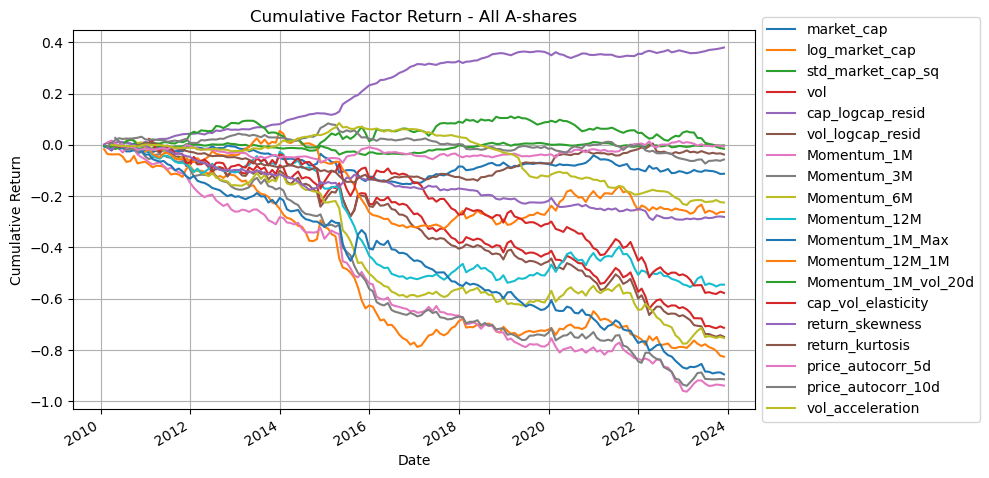

In [2]:
res_all_ashare, factor_ret_all_ashare = run_factor_analysis(universe_file=None, universe_name="All A-shares")

## 中证800


Factor Analysis: CSI 800
Universe from ../data/universe_800.csv shape: (168, 1625)

Factor Evaluation Results:


,IC,IC_positive,IR,Factor Mean Return,Factor Return tstat
market_cap,-0.009004,0.502994,-0.053187,0.000267,0.355962
log_market_cap,-0.009004,0.502994,-0.053187,-0.000636,-0.509902
std_market_cap_sq,0.017755,0.562874,0.242413,0.000322,0.775248
vol,-0.066030,0.341935,-0.325311,-0.004442,-2.942875
cap_logcap_resid,0.014952,0.526946,0.111892,0.000825,2.096567
vol_logcap_resid,-0.064642,0.348387,-0.340887,-0.004248,-3.009956
Momentum_1M,-0.039528,0.451807,-0.245921,-0.002899,-2.296190
Momentum_3M,-0.037773,0.445122,-0.217062,-0.002965,-2.193105
Momentum_6M,-0.017430,0.503106,-0.094087,-0.001722,-1.136508
Momentum_12M,-0.000437,0.519231,-0.002290,-0.000458,-0.308524


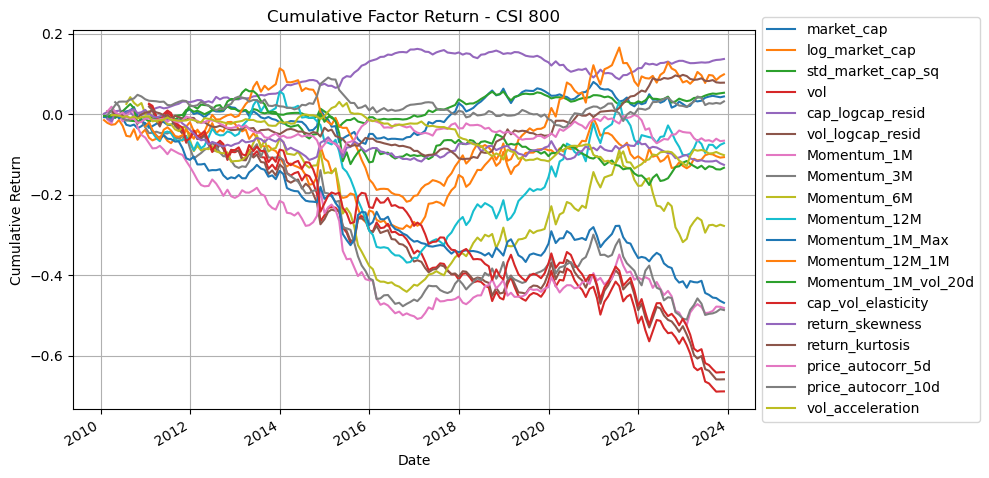

In [3]:
res_all_csi800, factor_ret_all_csi800 = run_factor_analysis(universe_file='../data/universe_800.csv', universe_name="CSI 800")

In [4]:
# Compare Different Universes
print("\n" + "="*60)
print("Comparison of All A-shares and CSI 800 Factor Analysis Results:")
print("="*60)

print("\nAll A-Shares vs CSI 800 IC:")
comparison_df = pd.DataFrame({
    'AShares_IC': res_all_ashare['IC'],
    'CSI800_IC': res_all_csi800['IC']
})
comparison_df['IC_diff'] = comparison_df['CSI800_IC'] - comparison_df['AShares_IC']
print(comparison_df.round(4))

print("\nAll A-Shares vs CSI 800 IR:")
ir_comparison_df = pd.DataFrame({
    'AShares_IR': res_all_ashare['IR'],
    'CSI800_IR': res_all_csi800['IR']
})
ir_comparison_df['IR_diff'] = ir_comparison_df['CSI800_IR'] - ir_comparison_df['AShares_IR']
print(ir_comparison_df.round(4))


Comparison of All A-shares and CSI 800 Factor Analysis Results:

All A-Shares vs CSI 800 IC:
                     AShares_IC  CSI800_IC  IC_diff
market_cap              -0.0516    -0.0090   0.0426
log_market_cap          -0.0516    -0.0090   0.0426
std_market_cap_sq        0.0411     0.0178  -0.0233
vol                     -0.0630    -0.0660  -0.0030
cap_logcap_resid         0.0522     0.0150  -0.0373
vol_logcap_resid        -0.0650    -0.0646   0.0004
Momentum_1M             -0.0616    -0.0395   0.0221
Momentum_3M             -0.0633    -0.0378   0.0255
Momentum_6M             -0.0482    -0.0174   0.0307
Momentum_12M            -0.0352    -0.0004   0.0347
Momentum_1M_Max         -0.0747    -0.0534   0.0214
Momentum_12M_1M         -0.0118     0.0148   0.0266
Momentum_1M_vol_20d      0.0052     0.0010  -0.0042
cap_vol_elasticity      -0.0521    -0.0619  -0.0098
return_skewness         -0.0356    -0.0204   0.0152
return_kurtosis          0.0007     0.0024   0.0017
price_autocorr_5d     